In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

%matplotlib inline



In [2]:
df = pd.read_csv('data/S06-hw-dataset-01.csv', sep=',', encoding='utf-8')
df.columns = df.columns.str.strip()


In [3]:
df.head()

,id,num01,num02,num03,num04,num05,num06,num07,num08,num09,...,num20,num21,num22,num23,num24,cat_contract,cat_region,cat_payment,tenure_months,target
0,1,-0.946058,-0.070313,1.824445,-2.754422,0.808865,-0.111094,-0.268950,-3.078210,0.801275,...,-1.616515,-1.989464,1.407390,-0.218362,2.016052,0,2,3,33,0
1,2,-2.484027,0.739378,1.596908,-2.586479,-0.033225,-3.054412,-4.706908,-9.795169,0.145911,...,-1.727040,-0.583997,1.136761,0.285978,-0.310879,2,2,2,102,1
2,3,1.522629,7.159635,-0.564903,-4.493110,1.623610,5.450187,-0.974595,-5.189589,1.600591,...,0.524408,2.022430,1.278358,-0.850547,0.847457,1,0,2,3,0
3,4,0.463373,-1.073908,1.752813,0.362786,2.790872,4.082385,0.322283,3.390984,-0.033929,...,2.399834,-1.431576,-0.746987,0.049639,2.414689,1,0,1,50,0
4,5,3.188390,-4.701692,-0.689918,-0.448995,0.373821,-3.275363,-1.760931,0.923689,0.537345,...,-2.183407,-2.896590,2.440343,-1.097168,1.457323,1,2,3,81,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             12000 non-null  int64  
 1   num01          12000 non-null  float64
 2   num02          12000 non-null  float64
 3   num03          12000 non-null  float64
 4   num04          12000 non-null  float64
 5   num05          12000 non-null  float64
 6   num06          12000 non-null  float64
 7   num07          12000 non-null  float64
 8   num08          12000 non-null  float64
 9   num09          12000 non-null  float64
 10  num10          12000 non-null  float64
 11  num11          12000 non-null  float64
 12  num12          12000 non-null  float64
 13  num13          12000 non-null  float64
 14  num14          12000 non-null  float64
 15  num15          12000 non-null  float64
 16  num16          12000 non-null  float64
 17  num17          12000 non-null  float64
 18  num18 

In [5]:
df.describe()

,id,num01,num02,num03,num04,num05,num06,num07,num08,num09,...,num20,num21,num22,num23,num24,cat_contract,cat_region,cat_payment,tenure_months,target
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,...,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,6000.50000,0.013705,-0.005278,-0.002357,0.038404,-0.006301,-0.865297,-0.702877,-0.290694,-0.008154,...,-0.323083,-1.314833,0.319798,-0.002742,0.027459,0.988750,1.990167,1.506833,36.083833,0.323417
std,3464.24595,2.096534,3.544498,1.004417,2.087318,1.007329,3.888966,1.989513,3.455981,0.996677,...,2.167066,3.731384,2.223649,0.996454,1.882359,0.815687,1.411643,1.121558,25.061218,0.467800
min,1.00000,-8.155181,-14.605579,-4.374043,-7.753301,-3.999332,-15.238402,-7.377252,-13.853627,-3.794637,...,-8.371050,-14.249204,-8.638879,-3.532093,-7.923990,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3000.75000,-1.423844,-2.303772,-0.685618,-1.374579,-0.676552,-3.532054,-2.064888,-2.597019,-0.683959,...,-1.808969,-3.863063,-1.097700,-0.676150,-1.110822,0.000000,1.000000,0.000000,17.000000,0.000000
50%,6000.50000,-0.047565,0.053348,-0.009186,0.038766,-0.003728,-1.092517,-0.795907,-0.208245,-0.020883,...,-0.383940,-1.393400,0.431804,0.006297,0.279689,1.000000,2.000000,2.000000,30.000000,0.000000
75%,9000.25000,1.422676,2.335937,0.671441,1.484417,0.669269,1.526389,0.522625,2.093169,0.666959,...,1.125140,1.116111,1.853491,0.657478,1.363896,2.000000,3.000000,3.000000,49.000000,1.000000
max,12000.00000,8.610863,16.299709,3.651692,7.571965,4.562115,16.223054,8.006444,13.030011,3.976868,...,7.957847,15.937281,8.102095,3.707905,7.549514,2.000000,4.000000,3.000000,120.000000,1.000000


In [6]:
print("Кол-во по классам:")
print(df['target'].value_counts())

print("\nДоля классов в процентах: ")
print(df['target'].value_counts(normalize=True) * 100)

Кол-во по классам:
target
0    8119
1    3881
Name: count, dtype: int64

Доля классов в процентах: 
target
0    67.658333
1    32.341667
Name: proportion, dtype: float64


In [7]:
#Количество пропусков в каждой колонке
print(df.isna().sum())

id               0
num01            0
num02            0
num03            0
num04            0
num05            0
num06            0
num07            0
num08            0
num09            0
num10            0
num11            0
num12            0
num13            0
num14            0
num15            0
num16            0
num17            0
num18            0
num19            0
num20            0
num21            0
num22            0
num23            0
num24            0
cat_contract     0
cat_region       0
cat_payment      0
tenure_months    0
target           0
dtype: int64


In [8]:
# Определяем признаки X
# Удаляем целевую переменную 'target' и технический столбец 'id'
x = df.drop(columns=['target', 'id'])

# Определяем целевую переменную y
y = df['target']

print(f"Форма признаков x: {x.shape}")
print(f"Форма признаков y: {y.shape}")


Форма признаков x: (12000, 28)
Форма признаков y: (12000,)


In [9]:
# Разделяем на обучающую (train) и тестовую (test) выборки

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# Проверка
print(f"Размер обучающей выборки: {x_train.shape[0]} строк")
print(f"Размер тестовой выборки: {x_test.shape[0]} строк")

Размер обучающей выборки: 9600 строк
Размер тестовой выборки: 2400 строк


## Seed и стратификация

Когда мы делим данные функцией train_test_split, компьютер делает это случайно. Чтобы этот процесс был под контролем, мы используем два важных параметра:

1. Random Seed (фиксация случайности): По умолчанию компьютер каждый раз будет перемешивать данные по-новому. Если мы зафиксируем random_state (например, числом 42), то при каждом запуске кода разделение на обучение и тест будет одинаковым. Это нужно для воспроизводимости: чтобы и ты, и преподаватель, и модель работали с одними и теми же наборами данных, а результаты не «прыгали» сами по себе.

2. Стратификация (сохранение пропорций): В нашем таргете есть два класса, и их количество неодинаково (например, 70% нулей и 30% единиц). Если делить данные просто так, есть риск, что в тест попадут почти одни нули, а модель так и не научится предсказывать единицы. Параметр stratify=y заставляет Python сохранить исходную пропорцию (70/30) и в тренировочной, и в тестовой выборке. Это делает обучение и проверку модели честными.

In [10]:
# Создаем глупую модель 

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(x_train, y_train)

dummy_preds = dummy.predict(x_test)

print(classification_report(y_test, dummy_preds, zero_division=0))

              precision    recall  f1-score   support

           0       0.68      1.00      0.81      1624
           1       0.00      0.00      0.00       776

    accuracy                           0.68      2400
   macro avg       0.34      0.50      0.40      2400
weighted avg       0.46      0.68      0.55      2400



In [11]:
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=42))
])

pipe_lr.fit(x_train, y_train)

lr_preds = pipe_lr.predict(x_test)

print(classification_report(y_test, lr_preds))

              precision    recall  f1-score   support

           0       0.84      0.91      0.88      1624
           1       0.78      0.65      0.71       776

    accuracy                           0.83      2400
   macro avg       0.81      0.78      0.79      2400
weighted avg       0.82      0.83      0.82      2400



# Dummy
Он нам нужен чтобы показать уровень пола. То есть если у нас есть 67% нулей, то он выдаст точность около 0.67 просто тыкая палбцем в небо. Наша модель обязана быть значительно лучше этого числа.
# Pipeline and StackingClassifier
Логистическая регрессия считает веса для признаковю Если один признак измеряется в милилионах, а другой в единицах, модель не прпиавильно решит какой признак важнее. StackingClassifier приводит все колонки к одиночному масшабу, чтоьы все было честно. 

In [12]:
dt_params = {
    'max_depth': [3, 5, 10, None],
    "min_samples_leaf": [1, 5, 10, 20]
}

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring='f1')
dt_grid.fit(x_train, y_train)

print(f"Лучшие параметры: {dt_grid.best_params_}")

dt_preds = dt_grid.predict(x_test)

Лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 5}


In [13]:
# RandomForestClassifier (Случайный лес)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='f1')
rf_grid.fit(x_train, y_train)

print(f"Лучшие результаты: {rf_grid.best_params_}")
rf_preds = rf_grid.predict(x_test)


Лучшие результаты: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}


In [14]:
# Boosting 
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5]
}

gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_params, cv = 5, scoring='f1', n_jobs=-1)
gb_grid.fit(x_train, y_train)

print(f"Лучшие парамметры: {gb_grid.best_params_}")
gb_preds = gb_grid.predict(x_test)

Лучшие парамметры: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}


In [15]:
# Расчет метрик (Accuracy, F1, ROC-AUC)
best_model = gb_grid.best_estimator_

# Предикты и вероятности
y_pred = best_model.predict(x_test)
y_probs = best_model.predict_proba(x_test)[:, 1] #колонка с вероятностью 1

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_probs):.4f}")

Accuracy: 0.9383
F1-Score: 0.9021
ROC-AUC:  0.9720


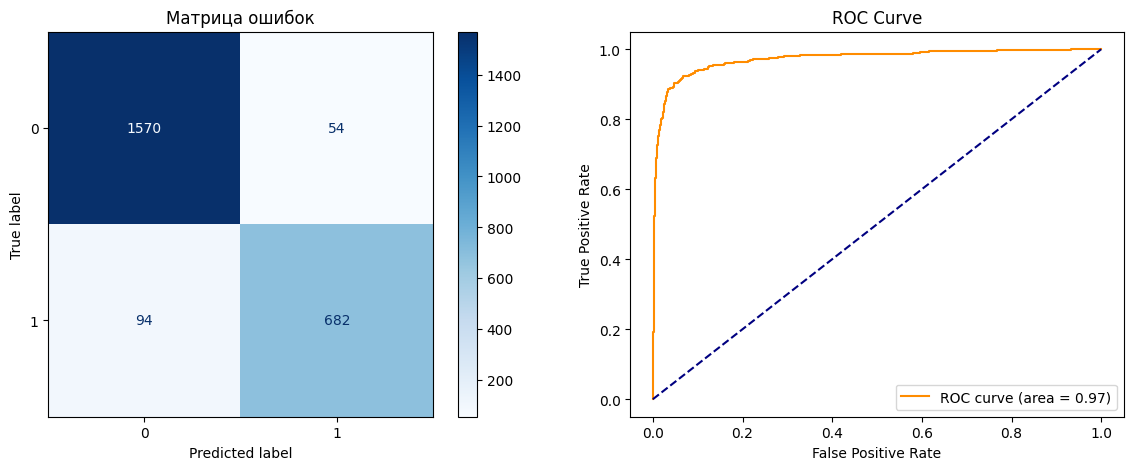

In [16]:
# График ROC-AUC

fig, ax = plt.subplots(1 ,2, figsize=(14, 5))

ConfusionMatrixDisplay.from_estimator(best_model, x_test, y_test, cmap='Blues', ax=ax[0])
ax[0].set_title("Матрица ошибок")

# ROC-кривая

fpr, tpr, _ = roc_curve(y_test, y_probs)
ax[1].plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc_score(y_test, y_probs):.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('ROC Curve')
ax[1].legend(loc="lower right")

os.makedirs('artifacts/figures', exist_ok=True)
plt.savefig('artifacts/figures/roc_auc_curve.png')
plt.show()


C:\Users\Maken\AppData\Local\Temp\ipykernel_16808\1829253606.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(10), x='importance', y='feature', palette='viridis')


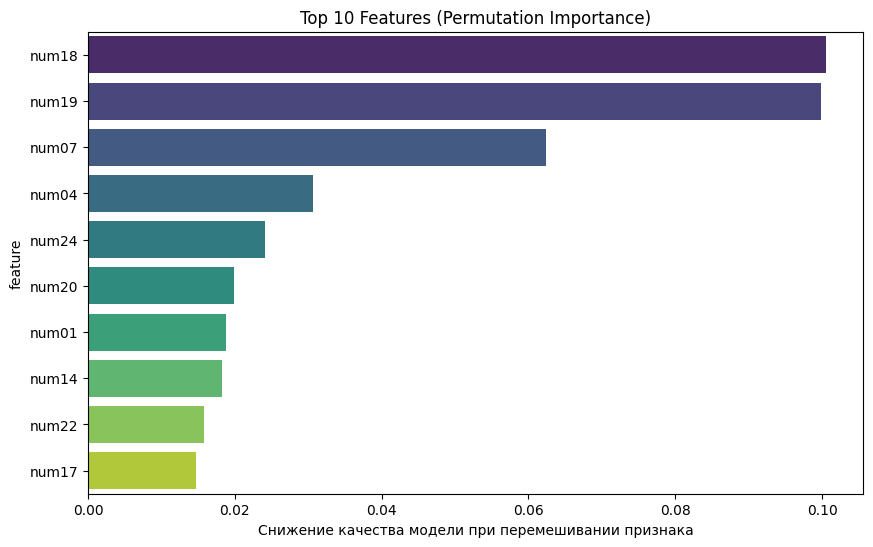

In [17]:
# Считаем важность на тестовой выборке
result = permutation_importance(
    best_model, x_test, y_test, 
    n_repeats=10,      # Повторяем 10 раз для точности
    random_state=42, 
    n_jobs=-1          
)

# Оформляем в красивую таблицу
importance_df = pd.DataFrame({
    'feature': x.columns,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

# Выводим Топ-10
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='importance', y='feature', palette='viridis')
plt.title('Top 10 Features (Permutation Importance)')
plt.xlabel('Снижение качества модели при перемешивании признака')
os.makedirs('artifacts/figures', exist_ok=True)
plt.savefig('artifacts/figures/feature_importance.png')
plt.show()

Лучшей моделью стал Gradient Boosting, показавший отличную обобщающую способность (ROC-AUC 0.97). Анализ важности признаков через перестановку (Permutation Importance) выявил, что ключевое влияние на прогноз оказывают переменные num18 и num19. Поскольку при их случайном изменении метрики качества падают сильнее всего, можно сделать вывод, что модель опирается на реальные зависимости в данных, а не на шум. Модель готова к использованию, так как значительно превосходит константный бейзлайн

In [18]:
# Сохранение метрик и лучших параметров

# 1. metrics_test.json — результаты всех моделей на тесте
metrics_test = {
    "dummy": {"accuracy": 0.67, "f1": 0.0}, # подставь свои значения из отчетов
    "log_reg": {"accuracy": 0.81, "f1": 0.75}, 
    "best_model_gb": {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_probs)
    }
}

os.makedirs('artifacts', exist_ok=True)
with open('artifacts/metrics_test.json', 'w') as f:
    json.dump(metrics_test, f, indent=4)

# 2. search_summaries.json — что нашел GridSearchCV
search_summaries = {
    "decision_tree": {"params": dt_grid.best_params_, "best_score": dt_grid.best_score_},
    "random_forest": {"params": rf_grid.best_params_, "best_score": rf_grid.best_score_},
    "gradient_boosting": {"params": gb_grid.best_params_, "best_score": gb_grid.best_score_}
}

with open('artifacts/search_summaries.json', 'w') as f:
    json.dump(search_summaries, f, indent=4)

In [19]:
# Сохранение модели и метаданных

# 3. best_model.joblib
os.makedirs('artifacts', exist_ok=True)
joblib.dump(best_model, 'artifacts/best_model.joblib')

# 4. best_model_meta.json
best_meta = {
    "model_type": "GradientBoostingClassifier",
    "best_params": gb_grid.best_params_,
    "test_metrics": metrics_test["best_model_gb"]
}

with open('artifacts/best_model_meta.json', 'w') as f:
    json.dump(best_meta, f, indent=4)
